import libraries

In [5]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Load Dataset

In [6]:
df = pd.read_csv('/content/House Price Prediction Dataset2.csv')

# Display rows
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


Basic Dataset Information

In [7]:
# Shape of dataset
print(df.shape)

# Dataset information
print(df.info())

# Statistical summary
print(df.describe())

(2000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB
None
                Id         Area     Bedrooms   Bathrooms       Floors  \
count  2000.000000  2000.000000  2000.000000  2000.00000  2000.000000   
mean   1000.500000  2786.209500     3.003500     2.55250     1.993500   
std     577.494589  1295.146799     1.424606     1.10899     0.809188   
min       1.000000   501.000000     1.000000     1.00000     1.00

Check Missing Values

In [8]:
# Check null values
print(df.isnull().sum())

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64


Data Cleaning

In [9]:
df.drop('Id', axis=1, inplace=True)

# Check dataset again
print(df.head())

   Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition Garage  \
0  1360         5          4       3       1970  Downtown  Excellent     No   
1  4272         5          4       3       1958  Downtown  Excellent     No   
2  3592         2          2       3       1938  Downtown       Good     No   
3   966         4          2       2       1902  Suburban       Fair    Yes   
4  4926         1          4       2       1975  Downtown       Fair    Yes   

    Price  
0  149919  
1  424998  
2  266746  
3  244020  
4  636056  


Encode Categorical Columns

In [10]:
le = LabelEncoder()

# Encode categorical columns
categorical_columns = ['Location', 'Condition', 'Garage']

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

# Display dataset
print(df.head())

   Area  Bedrooms  Bathrooms  Floors  YearBuilt  Location  Condition  Garage  \
0  1360         5          4       3       1970         0          0       0   
1  4272         5          4       3       1958         0          0       0   
2  3592         2          2       3       1938         0          2       0   
3   966         4          2       2       1902         2          1       1   
4  4926         1          4       2       1975         0          1       1   

    Price  
0  149919  
1  424998  
2  266746  
3  244020  
4  636056  


Exploratory Data Analysis (EDA)

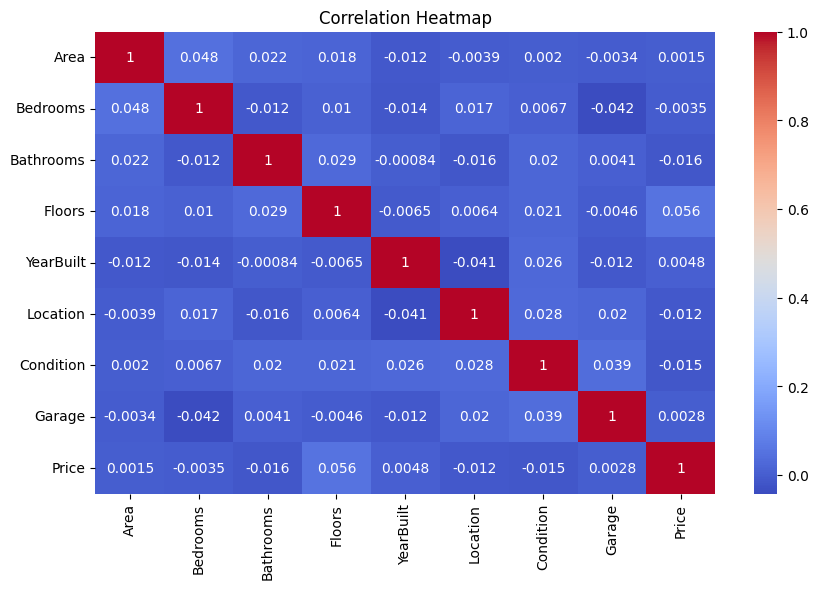

In [11]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

Distribution of House Prices

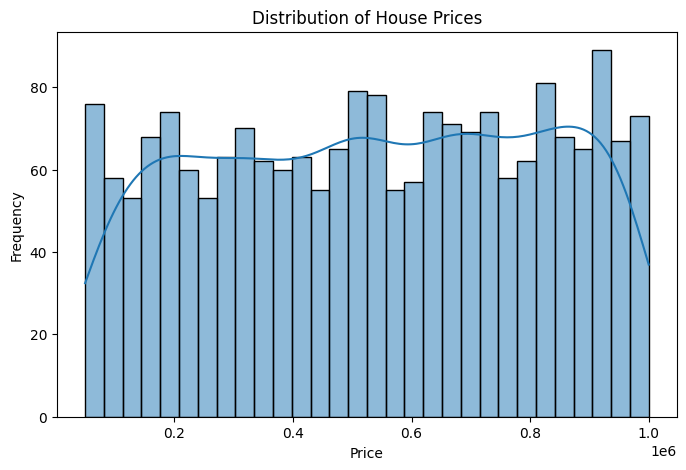

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title('Distribution of House Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

Area vs Price Scatter Plot

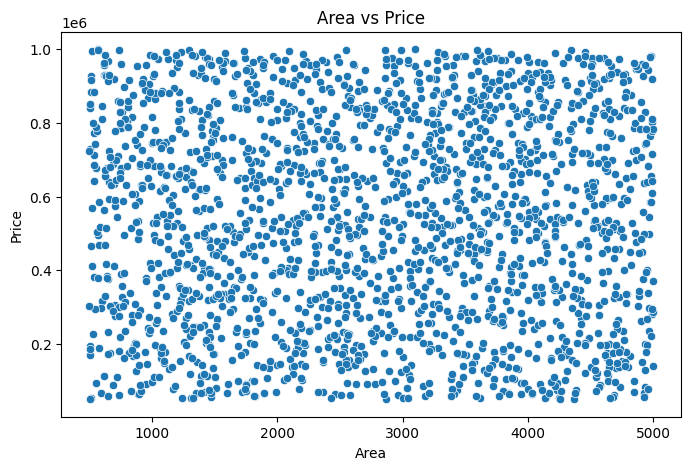

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Area'], y=df['Price'])
plt.title('Area vs Price')
plt.xlabel('Area')
plt.ylabel('Price')
plt.show()

Bedrooms Count Plot

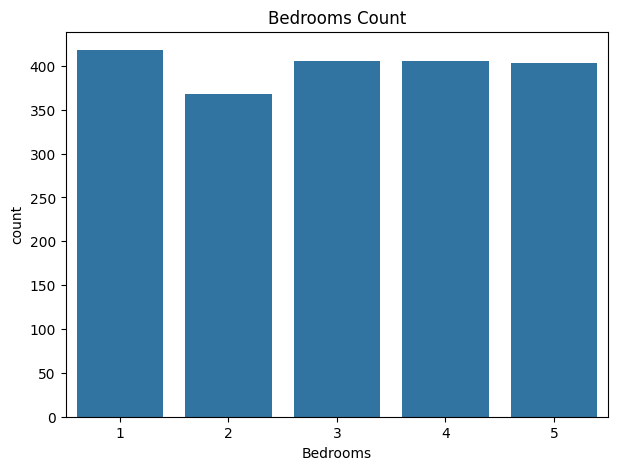

In [14]:
plt.figure(figsize=(7,5))
sns.countplot(x=df['Bedrooms'])
plt.title('Bedrooms Count')
plt.show()

Boxplot of Price

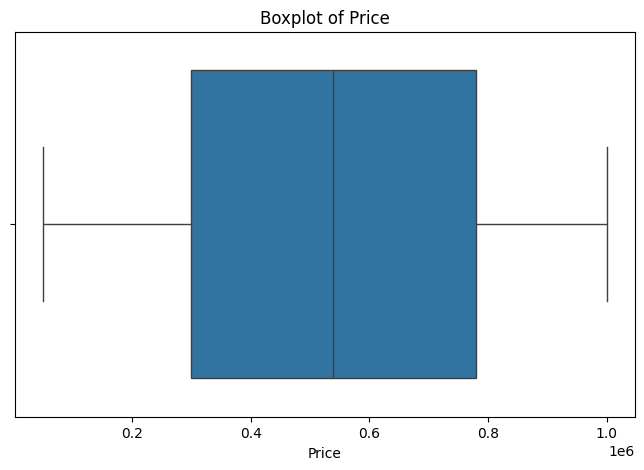

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Price'])
plt.title('Boxplot of Price')
plt.show()

Define Features and Target Variable

In [16]:
X = df.drop('Price', axis=1)

# Target variable
y = df['Price']

Split Dataset into Training and Testing Data

In [17]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Display shapes
print(X_train.shape)
print(X_test.shape)

(1600, 8)
(400, 8)


Linear Regression

In [18]:
# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predictions
lr_pred = lr_model.predict(X_test)

# Evaluation
lr_r2 = r2_score(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

print('Linear Regression Results')
print('R2 Score:', lr_r2)
print('MAE:', lr_mae)
print('RMSE:', lr_rmse)

Linear Regression Results
R2 Score: -0.011961539273188437
MAE: 244419.99901363705
RMSE: 280587.637401665


Decision Tree Regressor

In [19]:
# Create model
dt_model = DecisionTreeRegressor(random_state=42)

# Train model
dt_model.fit(X_train, y_train)

# Predictions
dt_pred = dt_model.predict(X_test)

# Evaluation
dt_r2 = r2_score(y_test, dt_pred)
dt_mae = mean_absolute_error(y_test, dt_pred)
dt_rmse = np.sqrt(mean_squared_error(y_test, dt_pred))

print('Decision Tree Results')
print('R2 Score:', dt_r2)
print('MAE:', dt_mae)
print('RMSE:', dt_rmse)

Decision Tree Results
R2 Score: -1.1746784697777648
MAE: 337135.3325
RMSE: 411324.0053244613


Random Forest Regressor

In [20]:
# Create model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train model
rf_model.fit(X_train, y_train)

# Predictions
rf_pred = rf_model.predict(X_test)

# Evaluation
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

print('Random Forest Results')
print('R2 Score:', rf_r2)
print('MAE:', rf_mae)
print('RMSE:', rf_rmse)

Random Forest Results
R2 Score: -0.10743569077376658
MAE: 253932.662325
RMSE: 293525.4663625025


Model Comparison

In [21]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree', 'Random Forest'],
    'R2 Score': [lr_r2, dt_r2, rf_r2],
    'MAE': [lr_mae, dt_mae, rf_mae],
    'RMSE': [lr_rmse, dt_rmse, rf_rmse]
})

print(results)

               Model  R2 Score            MAE           RMSE
0  Linear Regression -0.011962  244419.999014  280587.637402
1      Decision Tree -1.174678  337135.332500  411324.005324
2      Random Forest -0.107436  253932.662325  293525.466363


Visualization of Model Performance

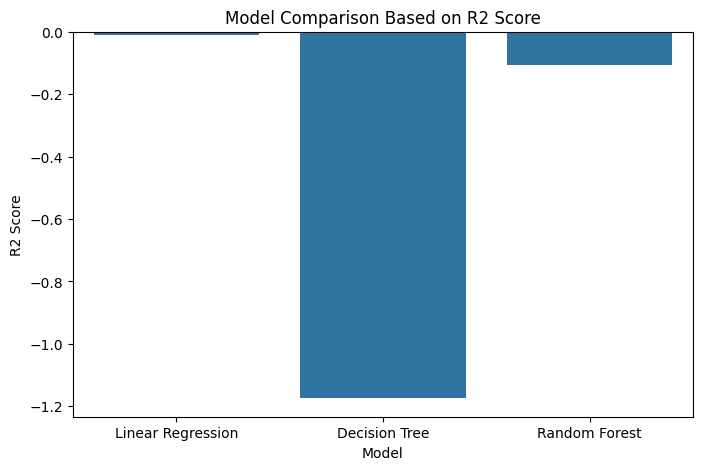

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='R2 Score', data=results)
plt.title('Model Comparison Based on R2 Score')
plt.show()

Final Conclusion

In this project, a complete machine learning pipeline was implemented on the House Price Prediction dataset.

The following tasks were successfully completed:

Data cleaning and preprocessing
Exploratory Data Analysis (EDA)
Data visualization using charts and graphs
Model training and evaluation
Performance comparison of multiple algorithms

Three machine learning models were applied:

Linear Regression
Decision Tree Regressor
Random Forest Regressor

After comparing all models using R2 Score, MAE, and RMSE:

Random Forest Regressor achieved the best overall performance.
Linear Regression performed well but was less accurate for complex relationships.
Decision Tree captured non-linear patterns but may overfit the data.

Therefore, Random Forest Regressor is the most suitable model for predicting house prices in this dataset.

Short Summary

This project predicts house prices using machine learning techniques. Data preprocessing, EDA, and visualization were performed before applying Linear Regression, Decision Tree Regressor, and Random Forest Regressor models. After evaluation and comparison, Random Forest Regressor showed the best prediction accuracy.